In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import cv2
import networkx as nx
import scipy.io as sio

from scipy.interpolate import Rbf, interpn
from skimage.morphology import thin
from PIL import Image, ImageEnhance

from src.crack_path.stress_calculation import principal_stress
from src.crack_graph.crack_to_graph import crack_to_graph, feature_extraction, draw_graph
from src.crack_segmentation.helper_func import polar_moment_of_area, moment_of_area

In [8]:
MASTER_PATH = "../Image-based load estimation/Data_Codes/All Images/5specimen/"
IMG_PATH = MASTER_PATH + "1.png"
img = cv2.imread(IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
Ip = polar_moment_of_area(img)
I = moment_of_area(img)
print(I[0], I[1])
print(Ip)

30057105.0 11122335.0
41179440.0


42


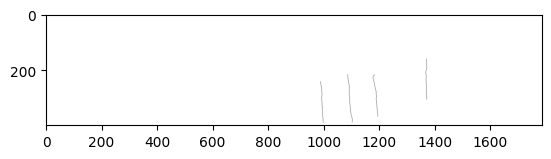

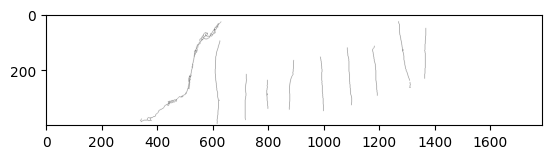

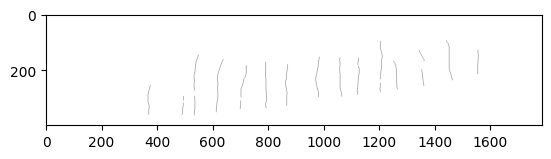

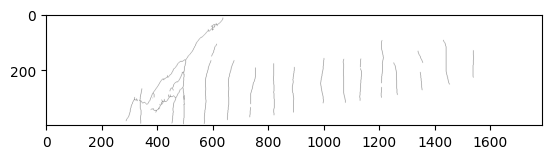

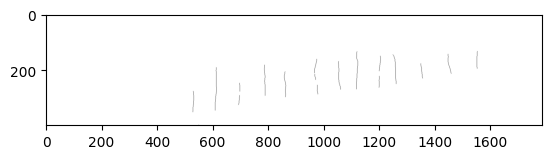

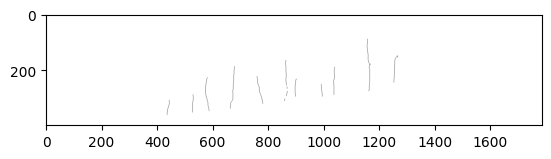

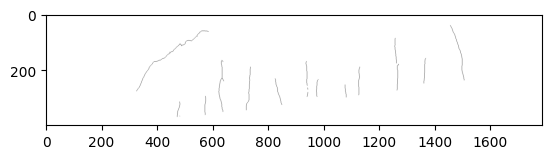

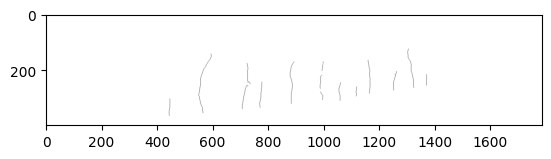

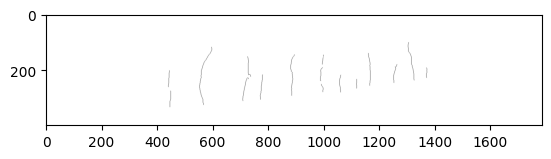

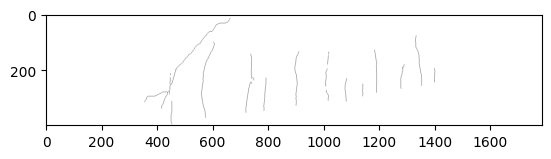

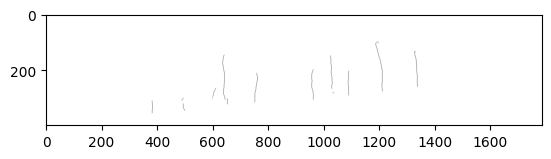

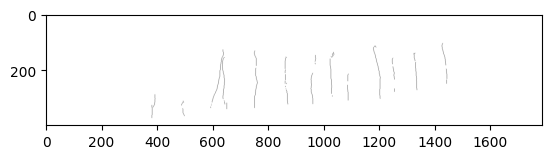

In [36]:
ROOT_PATH = '../Image-based load estimation/Data_Codes/Mat files/'
MAT_PATH = ROOT_PATH + 'Island_Scaled_segmented_ex_postcap_cropped_line.mat'

mat_data = sio.loadmat(MAT_PATH)
img_data = mat_data['Island_Scaled_segmented_ex_postcap_cropped_line']
print(len(img_data))
for i in range(len(img_data)-30):
    plt.imshow(img_data[i][0], cmap='binary')
    plt.show()
# plt.imshow(img_data[0][0])

In [2]:
# df_coord = pd.read_excel('../midas_output.xlsx', sheet_name='PLS300-coordinate')
# df_crack = pd.read_excel('../midas_output.xlsx', sheet_name='PLS300-crack')
# sknn_045 = pd.read_excel('../midas_output.xlsx', sheet_name='Sknn (0.45)')

# n_len = len(df_coord)
# temp_sknn_1 = [0 for _ in range(n_len)]
# temp_sknn_2 = [0 for _ in range(n_len)]
# temp_cwnn = [0 for _ in range(n_len)]

# for i in range(n_len):
#     element_to_search = df_coord['Element'][i]
#     sknn_1 = df_crack[df_crack['No'] == element_to_search]['Sknn'].values
#     sknn_2 = sknn_045[sknn_045['No'] == element_to_search]['Sknn'].values
#     cwnn = df_crack[df_crack['No'] == element_to_search]['Cwnn'].values
#     temp_sknn_1[i] = 0 if len(sknn_1) == 0 else sknn_1[0]
#     temp_sknn_2[i] = 0 if len(sknn_2) == 0 else sknn_2[0]
#     temp_cwnn[i] = 0 if len(cwnn) == 0 else cwnn[0]

# df_coord['Sknn_1'] = pd.Series(temp_sknn_1, index=df_coord.index)
# df_coord['Sknn_2'] = pd.Series(temp_sknn_2, index=df_coord.index)
# df_coord['Cwnn'] = pd.Series(temp_cwnn, index=df_coord.index)

# with pd.ExcelWriter('../PLS300_data.xlsx', mode='a') as writer:
#     df_coord.to_excel(writer, sheet_name='NewSheet1', index=False)

In [3]:
# df_sknn = pd.read_excel('../midas_output.xlsx', sheet_name='PLS300')
# df_sknn = df_sknn[df_sknn['Y'] == 0]
# df_sknn_len = len(df_sknn)

# df_sknn = df_sknn[0:df_sknn_len-4]

# sknn_plot_1 = np.array(df_sknn['Sknn_1'])
# sknn_plot_2 = np.array(df_sknn['Sknn_2'])
# cwnn_plot = np.array(df_sknn['Cwnn'])
# n_x = len(np.unique(df_sknn['X']))
# n_z = len(np.unique(df_sknn['Z']))
# sknn_plot_1 = sknn_plot_1.reshape(n_x, n_z).T
# sknn_plot_2 = sknn_plot_2.reshape(n_x, n_z).T
# cwnn_plot = cwnn_plot.reshape(n_x, n_z).T

# to_plot = [sknn_plot_1, sknn_plot_2, cwnn_plot]

# fig, axes = plt.subplots(3, 1, figsize=(30, 5), dpi=250)
# for ax, i in zip(axes.flat, range(3)):
#     im = ax.imshow(to_plot[i], origin='lower', cmap='jet')
#     ax.axis('off')

# plt.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.036, pad=0.02)
# plt.show()

In [4]:
df_sknn = pd.read_excel('../midas_output.xlsx', sheet_name='PLS300-half')
df_sknn = df_sknn[df_sknn['Y'] == 0]
df_sknn_len = len(df_sknn)

df_sknn = df_sknn[4:]

x = np.array(df_sknn['X'])
z = np.array(df_sknn['Z'])
spxx = np.array(df_sknn['SPXX'])
spzz = np.array(df_sknn['SPZZ'])
spxz = np.array(df_sknn['SPXZ'])

stress_max, stress_min, stress_angle = principal_stress(spxx, spzz, spxz)
k = 0.25 

sa = abs(stress_angle)
sm = stress_max

plt.figure(figsize=(30, 10))
plt.quiver(x, z, np.cos(np.radians(sa))*k, np.sin(np.radians(sa))*k, sm, scale=max(sm)*0.5, width=0.001, headwidth=5, pivot='mid', cmap='jet')

# sf_1 = axes[0].quiver(x, z, np.cos(np.radians(stress_angle_1))*k, np.sin(np.radians(stress_angle_1))*k, stress_max_1, scale=max(stress_max_1)*0.5, cmap='jet')
# sf_2 = axes[1].quiver(x, z, np.cos(np.radians(stress_angle_2))*k, np.sin(np.radians(stress_angle_2))*k, stress_max_2, scale=max(stress_max_2)*0.5, cmap='jet')

plt.colorbar(orientation='horizontal', fraction=0.36, pad=0.05)

FileNotFoundError: [Errno 2] No such file or directory: '../midas_output.xlsx'

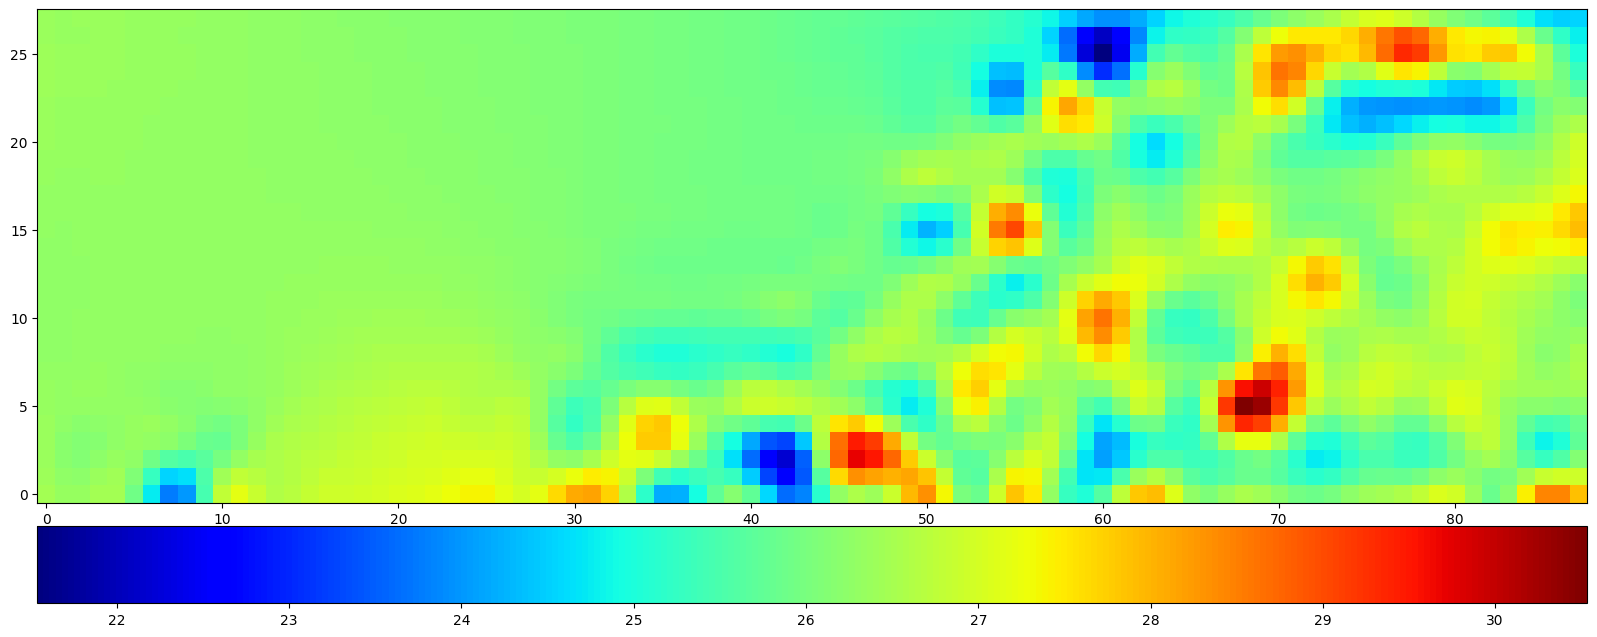

In [ ]:
x = np.array(df_sknn['X'])
z = np.array(df_sknn['Z'])

x_min, x_max = np.amin(x), np.amax(x)
z_min, z_max = np.amin(z), np.amax(z)

grid_x, grid_z = np.mgrid[x_min:x_max:10, z_min:z_max:10]

rbfi = Rbf(x, z, stress_max, functions='rbf')
di = rbfi(grid_x, grid_z)

plt.figure(figsize=(20, 10), dpi=100)
plt.imshow(di.T, origin='lower', cmap='jet')
plt.colorbar(orientation='horizontal', fraction=0.135, pad=0.03)

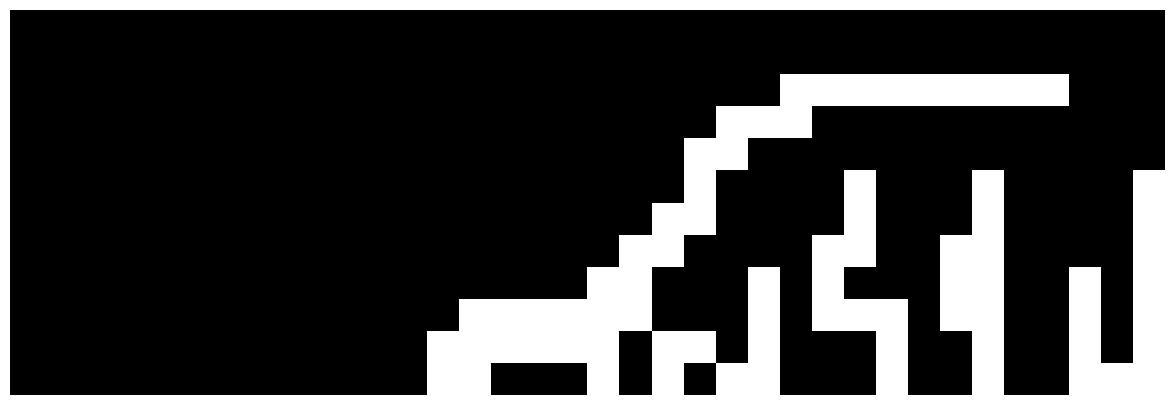

In [ ]:

E1_excel = pd.read_excel('../Data/midas_output.xlsx', sheet_name='PLS300-half')
E1_value = E1_excel[E1_excel['Y'] == 0]

E1_value = E1_value[4:]

x = np.array(E1_value['X'])   
z = np.array(E1_value['Z'])   
E1 = np.array(E1_value['E1'])

x_unique = np.unique(x)
z_unique = np.unique(z)

E1 = E1.reshape(len(x_unique), len(z_unique)).T

colors = ['black', 'white']
threshhold = 0.0005
bounds = [np.min(E1), threshhold, np.max(E1)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(20, 5), dpi=100)
# plt.title('Strain (E1)', fontsize=20, weight='bold')
plt.imshow(E1, origin='lower', cmap=cmap, norm=norm)

# plt.colorbar(orientation='horizontal', fraction=0.118, pad=0.09)
plt.axis(False)

# save figure
plt.savefig('./paper_figure/PLS300-half-segmented.png', dpi=250, bbox_inches='tight', pad_inches=0)

plt.show()


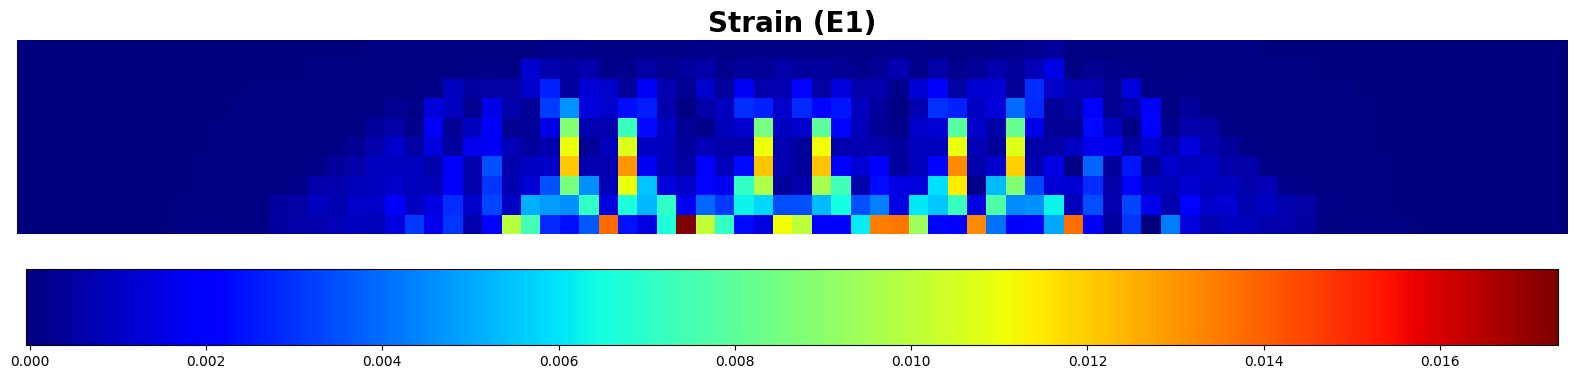

In [ ]:
colors = ['black', 'white']
threshhold = 0.0005
bounds = [0., threshhold, 0.008]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

E1_excel = pd.read_excel('../Data/midas_output.xlsx', sheet_name='FEA-error')
E1_value = E1_excel[E1_excel['Y'] == 0]

# E1_value = E1_value[4:]

x = np.array(E1_value['X'])   
z = np.array(E1_value['Z'])   
E1 = np.array(E1_value['E1_mid'])

x_unique = np.unique(x)
z_unique = np.unique(z)

E1 = E1.reshape(len(x_unique), len(z_unique)).T

plt.figure(figsize=(20, 5), dpi=100)
plt.title('Strain (E1)', fontsize=20, weight='bold')
plt.imshow(E1, origin='lower', cmap='jet')

plt.colorbar(orientation='horizontal', fraction=0.199, pad=0.09)
plt.axis(False)

# save figure
# plt.savefig('./paper_figure/PLS300-half-segmented.png', dpi=250, bbox_inches='tight', pad_inches=0)

plt.show()

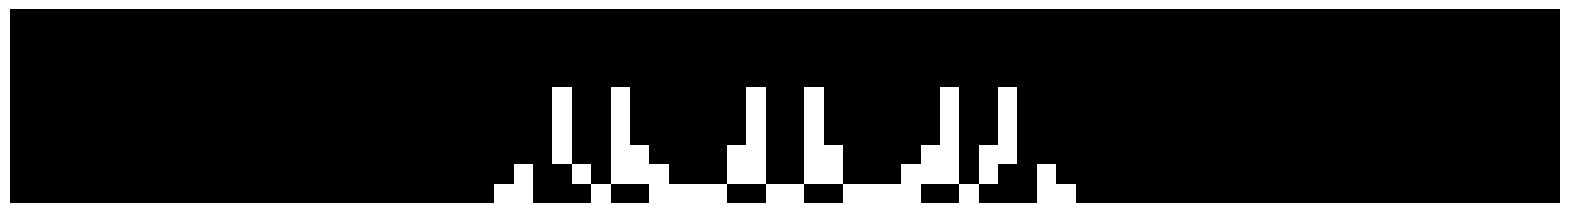

In [ ]:

colors = ['black', 'white']
threshhold = 0.005
bounds = [0., threshhold, 0.008]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

E1_excel = pd.read_excel('../Data/midas_output.xlsx', sheet_name='FEA-error')
E1_value = E1_excel[E1_excel['Y'] == 0]

# E1_value = E1_value[4:]

x = np.array(E1_value['X'])   
z = np.array(E1_value['Z'])   
E1 = np.array(E1_value['E1_mid'])

x_unique = np.unique(x)
z_unique = np.unique(z)

E1 = E1.reshape(len(x_unique), len(z_unique)).T

plt.figure(figsize=(20, 5), dpi=100)
# plt.title('Strain (E1)', fontsize=20, weight='bold')
plt.imshow(E1, origin='lower', cmap=cmap, norm=norm)

# plt.colorbar(orientation='horizontal', fraction=0.118, pad=0.09)
plt.axis(False)

# save figure
plt.savefig('./paper_figure/FEA_error-segmented.png', dpi=250, bbox_inches='tight', pad_inches=0)

plt.show()

(np.float64(-0.5), np.float64(2886.5), np.float64(961.5), np.float64(-0.5))

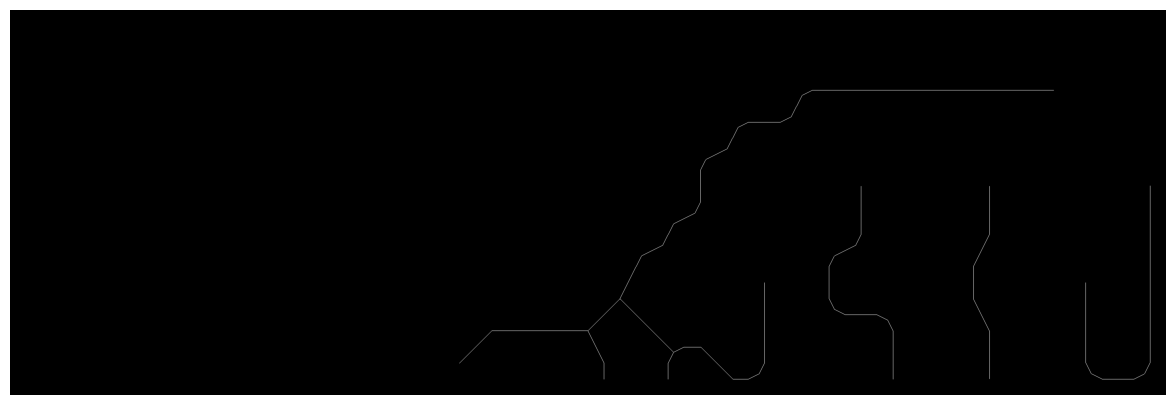

In [3]:
retrive_path = "./paper_figure/PLS300-half-segmented.png"
img = cv2.imread(retrive_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

thin_res = thin(img_gray)
plt.figure(figsize=(20, 5), dpi=100)
plt.imshow(thin_res, cmap='binary_r')
plt.axis(False)

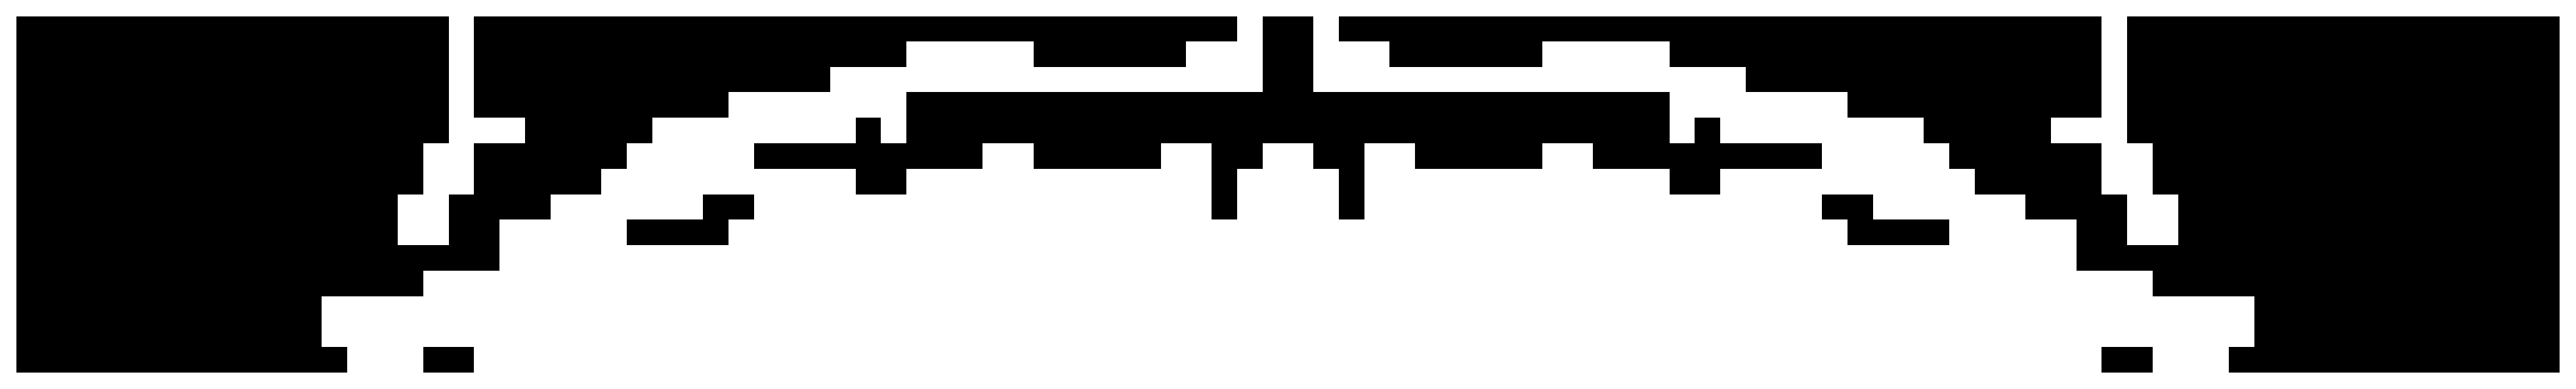

In [ ]:
crack_data = pd.read_excel('../Data/midas_output.xlsx', sheet_name='1L')
y = np.array(crack_data['Y'])
y_min = np.min(y)
crack_data = crack_data[crack_data['Y'] == y_min]
# crack_data = crack_data[4:]

x = np.array(crack_data['X'])
z = np.array(crack_data['Z'])

## Complete Data Range

x_unique = np.unique(x)
z_unique = np.unique(z)

for e in x_unique:
    temp_df = pd.DataFrame({'X': [e for _ in range(len(z_unique))], 'Z': z_unique})
    crack_data = pd.merge(crack_data, temp_df, left_on=['X', 'Z'], right_on=['X', 'Z'], how='outer').fillna(0)

# -------------------

# cw = np.array(crack_data['Cwnn (1)'])
cw = np.array(crack_data['CrackStatus (0.6)'])
cwnn_display = cw.reshape(len(x_unique), len(z_unique))
cwnn_display = cwnn_display.T
cwnn_display_h_flip = np.flip(cwnn_display, axis=1)
cwnn_display_full = np.hstack((cwnn_display, cwnn_display_h_flip))

plt.figure(figsize=(20, 5), dpi=250)
# plt.title('Crack Width (Load Step: 1.0)', fontsize=20, weight='bold')
plt.imshow(cwnn_display_full, cmap='binary_r', origin='lower')
plt.axis('off')

# plt.colorbar(orientation='horizontal', fraction=0.115, pad=0.06)
plt.savefig('./paper_figure/1L-CS-full-06.png', dpi=250, bbox_inches='tight', pad_inches=0)

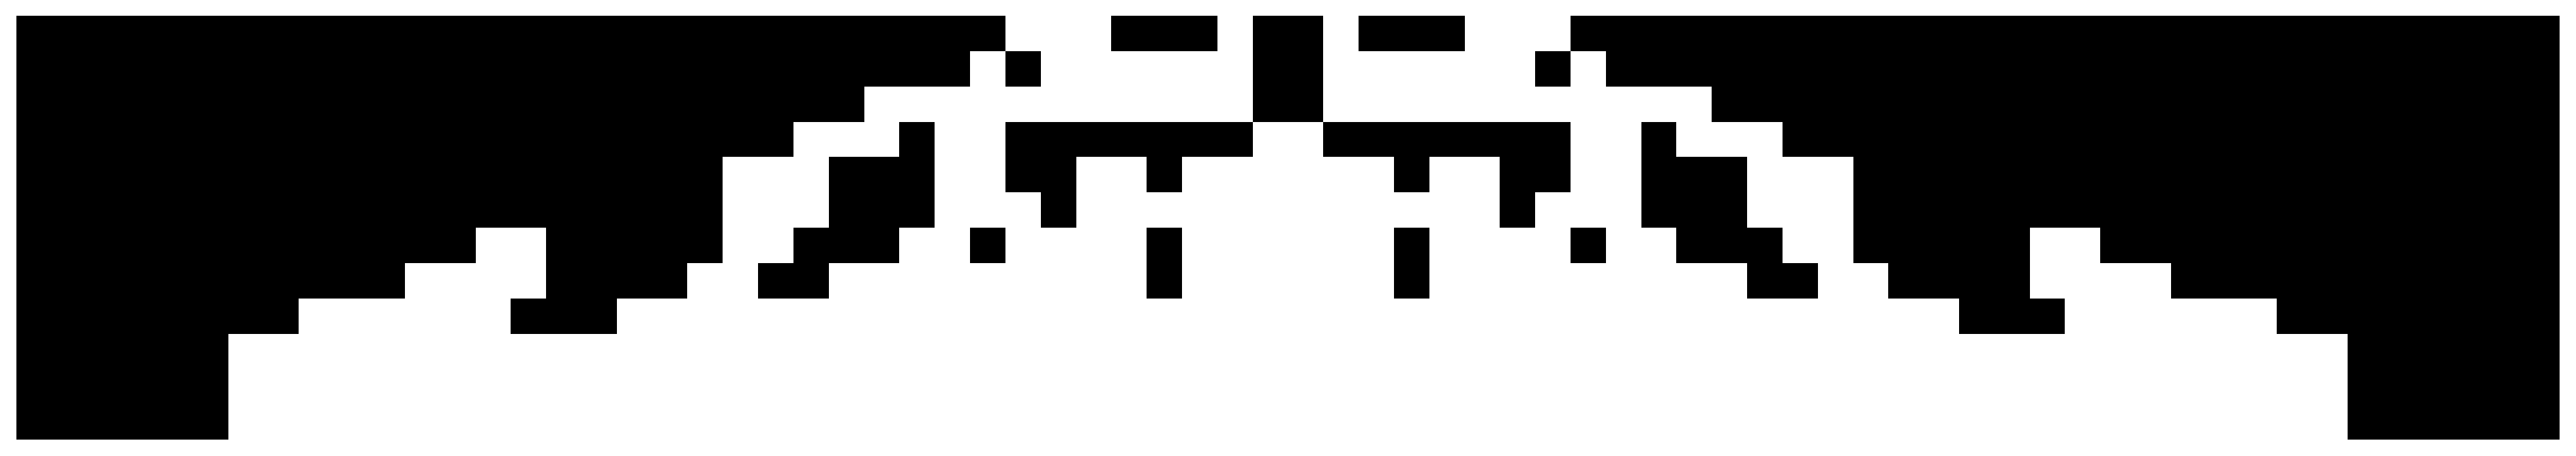

In [62]:
crack_data = pd.read_excel('../Data/midas_output.xlsx', sheet_name='PLS300-half')
y = np.array(crack_data['Y'])
crack_data = crack_data[crack_data['Y'] == 0]
crack_data = crack_data[4:]

x = np.array(crack_data['X'])
z = np.array(crack_data['Z'])

## Complete Data Range

x_unique = np.unique(x)
z_unique = np.unique(z)

for e in x_unique:
    temp_df = pd.DataFrame({'X': [e for _ in range(len(z_unique))], 'Z': z_unique})
    crack_data = pd.merge(crack_data, temp_df, left_on=['X', 'Z'], right_on=['X', 'Z'], how='outer').fillna(0)

# -------------------

# cw = np.array(crack_data['Cwnn (1)'])
cw = np.array(crack_data['CrackStatus (0.9)'])
cwnn_display = cw.reshape(len(x_unique), len(z_unique))
cwnn_display = cwnn_display.T
cwnn_display_h_flip = np.flip(cwnn_display, axis=1)
cwnn_display_full = np.hstack((cwnn_display, cwnn_display_h_flip))

plt.figure(figsize=(20, 5), dpi=250)
# plt.title('Crack Width (Load Step: 1.0)', fontsize=20, weight='bold')
plt.imshow(cwnn_display_full, cmap='binary_r', origin='lower')
plt.axis('off')

# plt.colorbar(orientation='horizontal', fraction=0.115, pad=0.06)
plt.savefig('./paper_figure/PLS300-CS-full-09.png', dpi=250, bbox_inches='tight', pad_inches=0)

In [48]:
# colors = ['black', 'white']
# threshhold = 0.05
# bounds = [np.min(cw), threshhold, np.max(cw)]
# cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(bounds, cmap.N)

# plt.figure(figsize=(20, 5), dpi=100)
# plt.imshow(cwnn_display.T, cmap=cmap, norm=norm, origin='lower')

# plt.axis(False)
# plt.savefig('./paper_figure/1L-segmented-1.png', dpi=250, bbox_inches='tight', pad_inches=0)

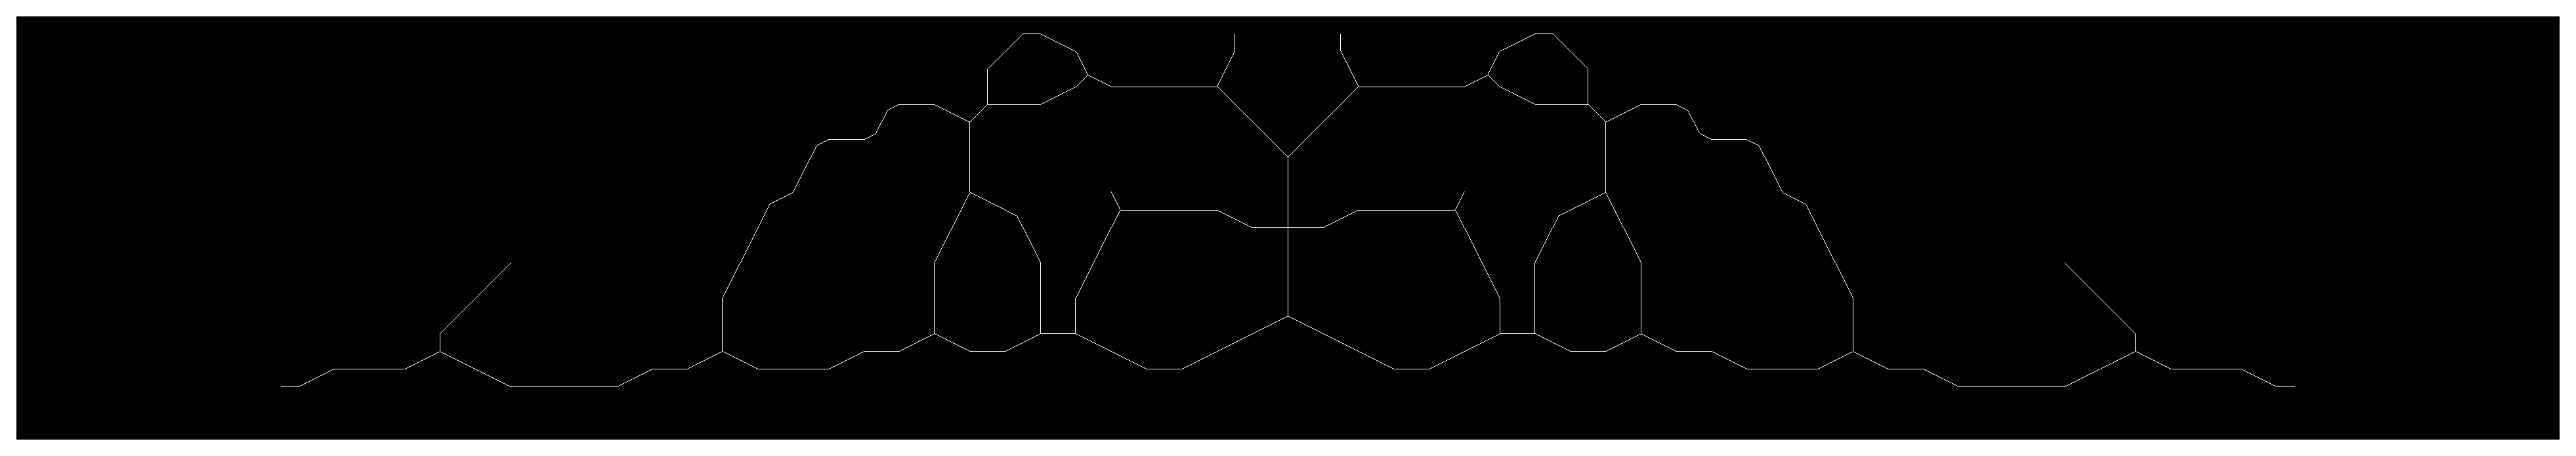

In [64]:
retrive_path = "./paper_figure/PLS300-CS-full-09.png"
img = cv2.imread(retrive_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

thin_res = thin(img_gray)
plt.figure(figsize=(20, 5), dpi=250)
plt.imshow(thin_res, cmap='binary_r')
plt.axis(False)

plt.savefig('./paper_figure/PLS300-thinned-09-CS-full.png', bbox_inches='tight', pad_inches=0)

In [ ]:
# cd = pd.read_excel('../midas_output.xlsx', sheet_name='crack_geometry')
# cd = cd[cd['Y'] == 7.291667]

# x = np.array(cd['X'])
# z = np.array(cd['Z'])
# cw = np.array(cd['Nonlinear(0.38) : LO-Solid,Cwnn'])

# x_min, x_max = np.amin(x), np.amax(x)
# z_min, z_max = np.amin(z), np.amax(z)

# grid_x, grid_z = np.mgrid[x_min:x_max:4, z_min:z_max:4]

# rbfi = Rbf(x, z, cw, function='linear')
# di = rbfi(grid_x, grid_z)

# plt.figure(figsize=(30, 10), dpi=250)
# plt.title('Crack Width (Load Step: 0.38)', fontsize=20, weight='bold')
# plt.imshow(di.T, origin='lower', cmap='jet')
# plt.colorbar(orientation='horizontal')
# plt.axis('off')

In [43]:
# stress_df = pd.read_excel('../midas_output.xlsx', sheet_name='FEA-error')

# sp = stress_df[stress_df['Y'] == 0]

# x = np.array(sp['X'])
# z = np.array(sp['Z'])
# spxx_1 = np.array(sp['SPXX_1'])
# spzz_1 = np.array(sp['SPZZ_1'])
# spxz_1 = np.array(sp['SPXZ_1'])
# spxx_2 = np.array(sp['SPXX_2'])
# spzz_2 = np.array(sp['SPZZ_2'])
# spxz_2 = np.array(sp['SPXZ_2'])

# # Principal stress calculation
# stress_max_1, stress_min_1, stress_angle_1 = principal_stress(spxx_1, spzz_1, spxz_1)
# stress_max_2, stress_min_2, stress_angle_2 = principal_stress(spxx_2, spzz_2, spxz_2)
# k = 1.3

# fig, axes = plt.subplots(2, 1, figsize=(30, 15), dpi=250)

# for i in range(len(x)):
#     if x[i] >= 600:
#         stress_angle_1[i] = 180 - stress_angle_1[i]
#         stress_angle_2[i] = 180 - stress_angle_2[i]

# sa = [stress_angle_1, stress_angle_2]
# sm = [stress_max_1, stress_max_2]

# for ax, i in zip(axes, range(2)):
#     im = ax.quiver(x, z, np.cos(np.radians(sa[i]))*k, np.sin(np.radians(sa[i]))*k, sm[i], scale=max(sm[i])*0.5, width=0.001, headwidth=5, cmap='jet')

# # sf_1 = axes[0].quiver(x, z, np.cos(np.radians(stress_angle_1))*k, np.sin(np.radians(stress_angle_1))*k, stress_max_1, scale=max(stress_max_1)*0.5, cmap='jet')
# # sf_2 = axes[1].quiver(x, z, np.cos(np.radians(stress_angle_2))*k, np.sin(np.radians(stress_angle_2))*k, stress_max_2, scale=max(stress_max_2)*0.5, cmap='jet')

# cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.36, pad=0.03)

In [44]:
# x = np.array(sp['X'])
# z = np.array(sp['Z'])

# x_min, x_max = np.amin(x), np.amax(x)
# z_min, z_max = np.amin(z), np.amax(z)

# grid_x, grid_z = np.mgrid[x_min:x_max:1, z_min:z_max:1]

# rbfi = Rbf(x, z, stress_max_1, functions='linear')
# di = rbfi(grid_x, grid_z)

# plt.figure(figsize=(30, 10), dpi=250)
# plt.imshow(di.T, origin='lower', cmap='jet')
# plt.colorbar(orientation='horizontal')

In [3]:
from src.crack_graph.crack_to_graph import crack_to_graph, feature_extraction, draw_graph

# IMG_PATH = './../../FractalDatabase/20241201_090401_color_mask.png'
# os.chdir('../FractalDatabase')
# IMG_PATH = 'C/Users/ilham/Documents/Sipil/S2/THESIS/CrackSegmentation/FractalDatabase/20241201_090401_color_mask.png'
# IMG_PATH = 'Fractal Database/20241201_090401_color_mask.png'
IMG_PATH = './paper_figure/1L-thin-025-CS-full.png'

# test = imageio.imread(IMG_PATH)

edges, edges_dict, nodes, nodes_dict, img_bin, img_plot = crack_to_graph(IMG_PATH)

graph_feature = feature_extraction(edges_dict, nodes_dict)

c:\Users\ilham\Documents\Sipil\S2\THESIS\Coding\lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ilham\Documents\Sipil\S2\THESIS\Coding\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ZeroDivisionError: division by zero

In [ ]:
from src.crack_graph.crack_to_graph import adj_mat

adj_matrix = adj_mat(nodes, edges_dict)
G = nx.Graph(adj_matrix)

# g_e = (nx.global_efficiency(G.subgraph(G[v])) for v in G)
# l_e = nx.local_efficiency(G)
# print("l_e:", (sum(g_e)/len(G)), end='\n\n')

for v in G:
    g_subg = G.subgraph(G[v])
    print(f"{nx.global_efficiency(G.subgraph(G[v])):.3f}\t {g_subg}\t {G[v]}")

Graph with 0 nodes and 0 edges


In [6]:
i = 0
for edge_t, edge_v in zip(edges_dict.items(), edges.values()):
    _, v = edge_t
    print(i,"\t", v, edge_v)
    i = i + 1

0 	 ['0', '24', np.float64(5.83)] ([np.int64(1453), np.int64(332)], [np.int64(1448), np.int64(335)])
1 	 ['0', '185', np.float64(5.83)] ([np.int64(1453), np.int64(332)], [np.int64(1456), np.int64(327)])
2 	 ['0', '238', np.float64(12.73)] ([np.int64(1453), np.int64(332)], [np.int64(1462), np.int64(341)])
3 	 ['1', '239', np.float64(2.0)] ([1411, 329], [1413, 329])
4 	 ['2', '50', np.float64(7.81)] ([np.int64(1371), np.int64(406)], [np.int64(1376), np.int64(412)])
5 	 ['2', '135', np.float64(11.18)] ([np.int64(1371), np.int64(406)], [np.int64(1376), np.int64(396)])
6 	 ['2', '111', np.float64(13.0)] ([np.int64(1371), np.int64(406)], [np.int64(1359), np.int64(411)])
7 	 ['3', '136', np.float64(7.62)] ([545, 396], [542, 403])
8 	 ['3', '45', np.float64(20.52)] ([545, 396], [531, 381])
9 	 ['3', '240', np.float64(28.0)] ([545, 396], [573, 396])
10 	 ['4', '241', np.float64(1.41)] ([1322, 393], [1323, 394])
11 	 ['4', '365', np.float64(10.63)] ([1322, 393], [1315, 401])
12 	 ['4', '367', np

In [8]:
subg = dict(list(edges.items())[31:34])
for i in subg.values():
    print(i[0], i[1])

[np.int64(1453), np.int64(390)] [np.int64(1445), np.int64(393)]
[np.int64(821), np.int64(232)] [np.int64(823), np.int64(231)]
[np.int64(821), np.int64(232)] [np.int64(823), np.int64(235)]


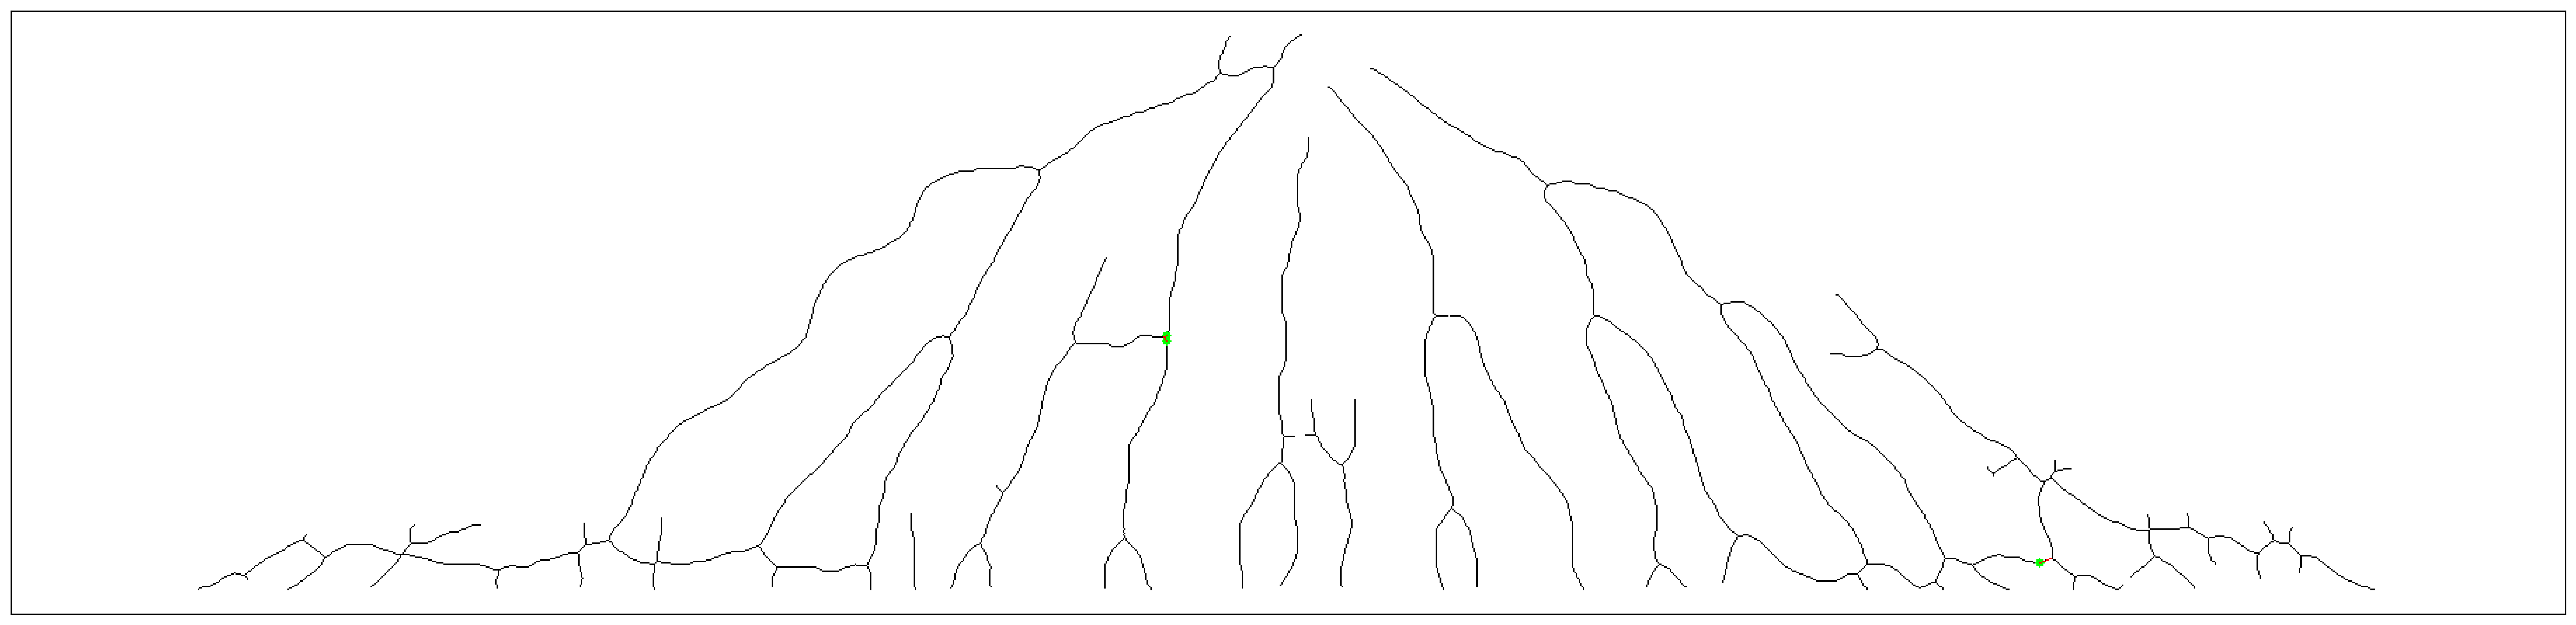

: 

In [ ]:
plt.figure(figsize=(30, 10), dpi=250)
circle_thickness = max(int(np.floor(min(0.004*img_bin.shape[0], 0.004*img_bin.shape[1]))),3)
for i in subg.values():
    _, value = i[0], i[1]
    cv2.circle(img_plot, (value[0], value[1]), circle_thickness, (0,255,0), -1)    # draw circles on the corner

# ##### Resulting Image
for value in subg.values():
    cv2.line(img_plot, value[0], value[1], (255,0,0), thickness=1, lineType=8)

# fig, ax = plt.subplots()
plt.xticks([])
plt.yticks([])
plt.imshow(img_plot, cmap = None)

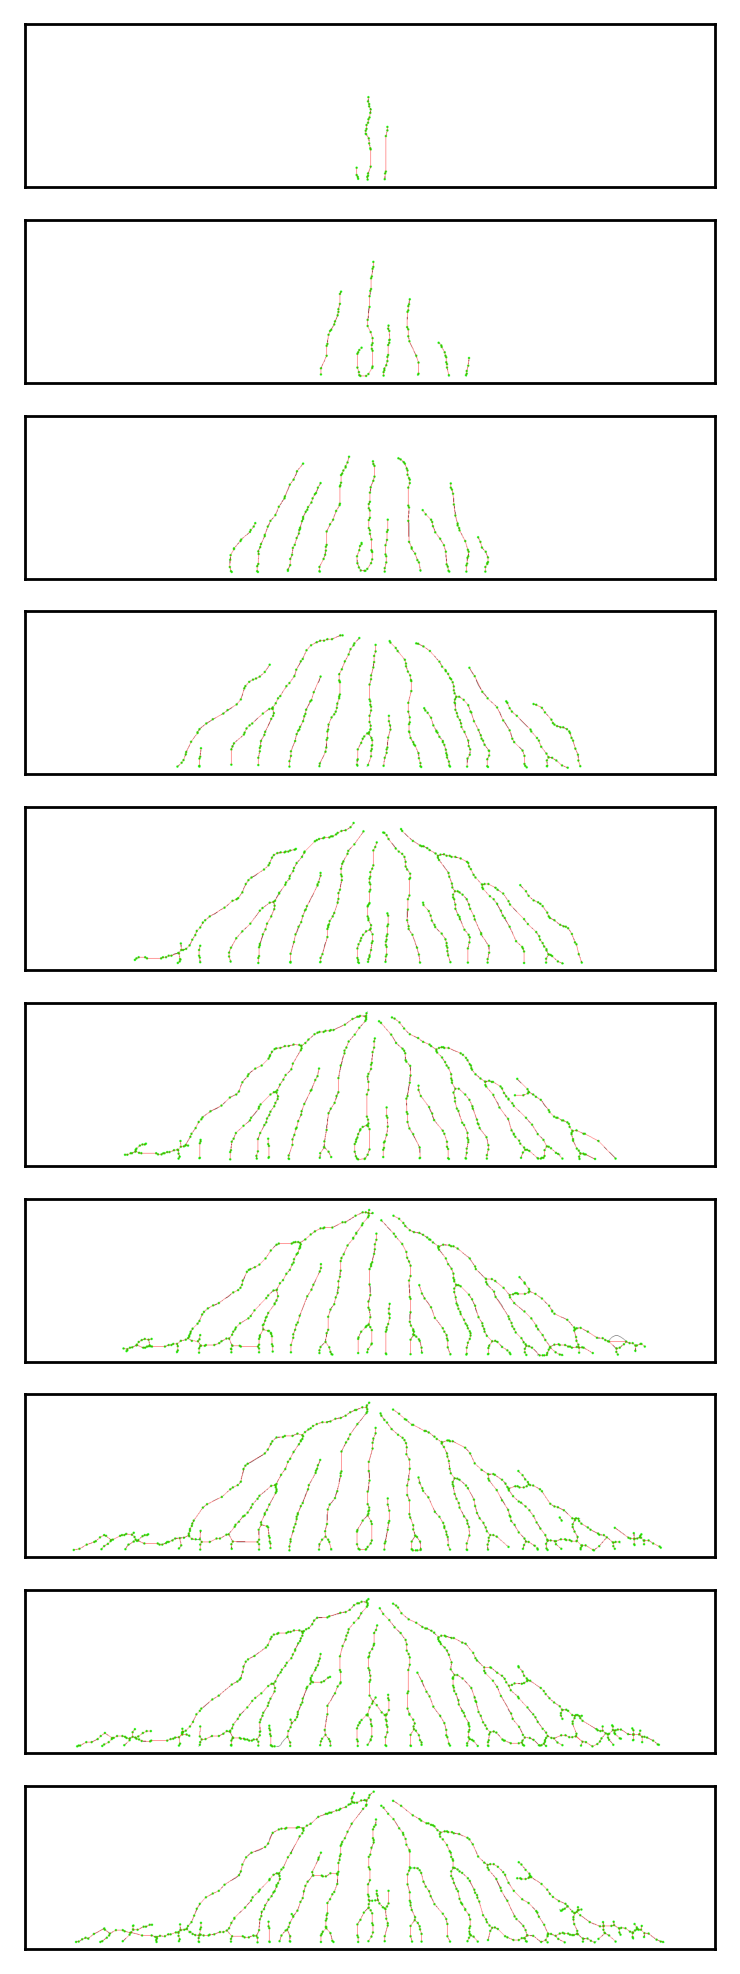

: 

In [ ]:
start = 13
end = 23
img_num = list(range(start, end))
plot_len = len(img_num)
MASTER_PATH = "../Image-based load estimation/Data_Codes/All Images/5specimen/"
# load_step_file = ['025', '038', '05', '063', '076', '088', '1']
# IMG_PATH_ARRAY = [f'./paper_figure/1L-thin-{step}-CS-full.png' for step in load_step_file]

plt.figure(figsize=(30, 10), dpi=250)

for i, num in enumerate(img_num):
    img_path = MASTER_PATH + f"{num}.png"
    edges, edges_dict, nodes, nodes_dict, img_bin, img_plot = crack_to_graph(img_path)
    graph_feature = feature_extraction(edges_dict, nodes_dict)
    plt.subplot(plot_len, 1, i+1)
    draw_graph(img_bin, img_plot, edges, nodes, img_name="", save_plot=False)

# plt.savefig(f'./paper_figure/5specimen-img-{start}-{end}-dense')
# plt.show()